
Ni_R1s(r) =
+291.1578 * exp(-28.7266 r)
+206.2379 * r * exp(-24.5237 r)
+0.0838 * r * exp(-11.7009 r)
+889.1833 * r^2 * exp(-35.2606 r)
-0.0693 * r^2 * exp(-8.3190 r)
-0.0096 * r^2 * exp(-5.8931 r)
+0.0004 * r^2 * exp(-4.0420 r)
+3.8189 * r^3 * exp(-14.1323 r)
-0.0000 * r^3 * exp(-2.4332 r)
+0.0000 * r^3 * exp(-1.5225 r)
-0.0000 * r^3 * exp(-0.9912 r)

Ni_R2s(r) =
+89.1666 * exp(-28.7266 r)
+643.3335 * r * exp(-24.5237 r)
-580.4048 * r * exp(-11.7009 r)
+15.2569 * r^2 * exp(-35.2606 r)
-44.6104 * r^2 * exp(-8.3190 r)
+1.9023 * r^2 * exp(-5.8931 r)
-0.1842 * r^2 * exp(-4.0420 r)
-734.5514 * r^3 * exp(-14.1323 r)
+0.0025 * r^3 * exp(-2.4332 r)
-0.0002 * r^3 * exp(-1.5225 r)
+0.0000 * r^3 * exp(-0.9912 r)

Ni_R3s(r) =
-33.4058 * exp(-28.7266 r)
-285.5416 * r * exp(-24.5237 r)
+262.9562 * r * exp(-11.7009 r)
-104.2741 * r^2 * exp(-35.2606 r)
+2.3343 * r^2 * exp(-8.3190 r)
-143.6235 * r^2 * exp(-5.8931 r)
-26.5915 * r^2 * exp(-4.0420 r)
+1792.7819 * r^3 * exp(-14.1323 r)
-0.0256 * r^3 * ex

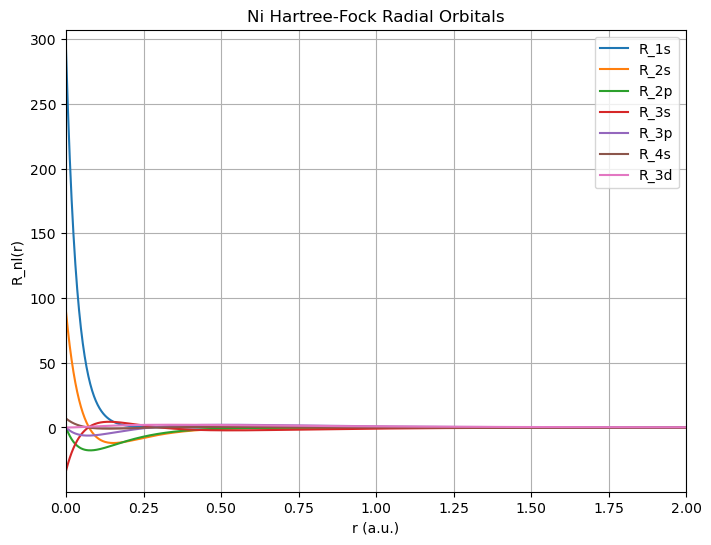

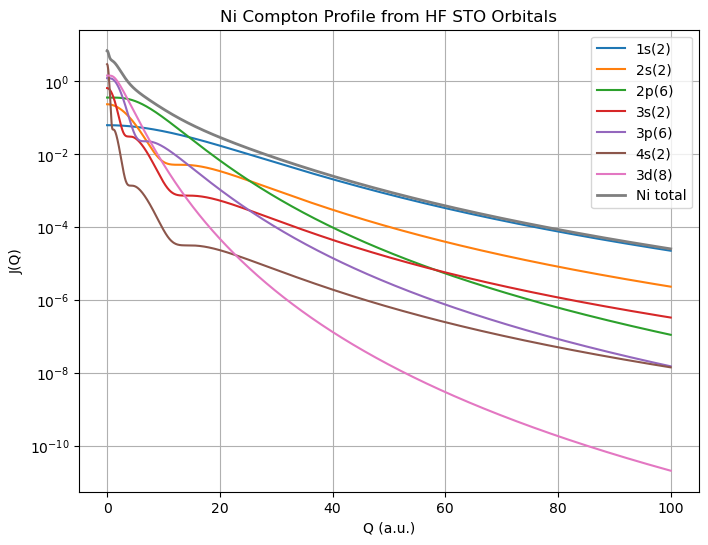

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import spherical_jn, factorial
from scipy.integrate import cumulative_trapezoid

# =====================================================
# Copper Hartree-Fock STO data
# Cu: 1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(1) 
# Ground term: 4S
# Format: (n_j, Z_j, C_j)
# =====================================================

# =====================================================
# 1s orbital
# =====================================================

nickel_1s = [
    (1, 28.7266,  0.945523),
    (2, 24.5237,  0.059970),
    (2, 11.7009,  0.000155),
    (3, 35.2606,  0.008101),
    (3,  8.3190, -0.000099),
    (3,  5.8931, -0.000046),
    (3,  4.0420,  0.000008),
    (4, 14.1323,  0.000226),
    (4,  2.4332, -0.000005),
    (4,  1.5225,  0.000003),
    (4,  0.9912, -0.000001),
]


# =====================================================
# 2s orbital
# =====================================================

nickel_2s = [
    (1, 28.7266,  0.289565),
    (2, 24.5237,  0.187069),
    (2, 11.7009, -1.073281),
    (3, 35.2606,  0.000139),
    (3,  8.3190, -0.063716),
    (3,  5.8931,  0.009081),
    (3,  4.0420, -0.003291),
    (4, 14.1323, -0.043470),
    (4,  2.4332,  0.000399),
    (4,  1.5225, -0.000214),
    (4,  0.9912,  0.000071),
]


# =====================================================
# 3s orbital
# =====================================================

nickel_3s = [
    (1, 28.7266, -0.108484),
    (2, 24.5237, -0.083030),
    (2, 11.7009,  0.486257),
    (3, 35.2606, -0.000950),
    (3,  8.3190,  0.003334),
    (3,  5.8931, -0.685620),
    (3,  4.0420, -0.475026),
    (4, 14.1323,  0.106095),
    (4,  2.4332, -0.004158),
    (4,  1.5225,  0.000568),
    (4,  0.9912, -0.000119),
]


# =====================================================
# 4s orbital
# =====================================================

nickel_4s = [
    (1, 28.7266,  0.022468),
    (2, 24.5237,  0.017547),
    (2, 11.7009, -0.102978),
    (3, 35.2606,  0.000219),
    (3,  8.3190, -0.004844),
    (3,  5.8931,  0.182371),
    (3,  4.0420,  0.094382),
    (4, 14.1323, -0.024948),
    (4,  2.4332, -0.283769),
    (4,  1.5225, -0.538297),
    (4,  0.9912, -0.308953),
]


# =====================================================
# 2p orbital
# =====================================================

nickel_2p = [
    (2, 46.7514, -0.000470),
    (2, 17.7675, -0.319845),
    (2,  9.5726, -0.438165),
    (2,  4.5914, -0.006828),
    (3, 14.5116, -0.285978),
    (3,  3.7535,  0.000547),
    (3,  2.4658, -0.000255),
]


# =====================================================
# 3p orbital
# =====================================================

nickel_3p = [
    (2, 46.7514, -0.000119),
    (2, 17.7675, -0.067683),
    (2,  9.5726, -0.527884),
    (2,  4.5914,  0.810679),
    (3, 14.5116, -0.020283),
    (3,  3.7535,  0.421372),
    (3,  2.4658,  0.049664),
]


# =====================================================
# 3d orbital
# =====================================================

nickel_3d = [
    (3, 13.9008,  0.017517),
    (3,  7.3628,  0.225100),
    (3,  4.4602,  0.419212),
    (3,  2.6365,  0.376659),
    (3,  1.5875,  0.130041),
]

# =====================================================
# STO normalization constant
# N_j = sqrt((2Z)^(2n+1)/(2n)!)
# =====================================================
def N_sto(n, Z):
    return np.sqrt((2*Z)**(2*n + 1) / factorial(2*n, exact=False))

def R_nl(r, coeffs):
    R = np.zeros_like(r)
    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        R += C * N * r**(n-1) * np.exp(-Z*r)
    return R
# =====================================================
# Grids
# =====================================================

r = np.linspace(1e-6, 60.0, 20000)     # radial grid
p = np.arange(0.0, 1000.0 + 0.05, 0.05) # momentum grid
Q = np.arange(0.0, 100.0 + 0.05, 0.05) # Q grid

# =====================================================
# Calculate chi_nl(p)
# chi_nl(p) = sqrt(2/pi) int R_nl(r) j_l(pr) r^2 dr
# =====================================================

def chi_p(p_grid, r_grid, R_grid, l):
    chi = []

    for pp in p_grid:
        jl = spherical_jn(l, pp*r_grid)
        integrand = R_grid * jl * r_grid**2
        val = np.sqrt(2/np.pi) * np.trapezoid(integrand, r_grid)
        chi.append(val)

    return np.array(chi)

# =====================================================
# Calculate J(Q)
# I(p) = |chi(p)|^2 p^2
# J(Q) = 1/2 int_Q^inf I(p)/p dp
# =====================================================

def calculate_J(p_grid, chi_grid, Q_grid):
    I = chi_grid**2 * p_grid**2

    integrand = np.zeros_like(p_grid)
    integrand[1:] = I[1:] / p_grid[1:]

    # Reverse cumulative integral from p to infinity
    rev_integral = cumulative_trapezoid(
        integrand[::-1],
        p_grid[::-1],
        initial=0
    )

    J_p = -0.5 * rev_integral[::-1]

    # Interpolate J from p-grid to Q-grid
    J_Q = np.interp(Q_grid, p_grid, J_p)

    return I, J_Q

# =====================================================
# Build Copper radial orbitals
# =====================================================
def print_R_formula(coeffs, name):
    print(f"\n{name}(r) =")

    for n, Z, C in coeffs:
        N = N_sto(n, Z)
        A = C * N

        if n == 1:
            print(f"{A:+.4f} * exp(-{Z:.4f} r)")
        elif n == 2:
            print(f"{A:+.4f} * r * exp(-{Z:.4f} r)")
        elif n == 3:
            print(f"{A:+.4f} * r^2 * exp(-{Z:.4f} r)")
        elif n == 4:
            print(f"{A:+.4f} * r^3 * exp(-{Z:.4f} r)")
            
# =====================================================
# Build Nickel radial orbitals
# =====================================================

R1s = R_nl(r, nickel_1s)
R2s = R_nl(r, nickel_2s)
R3s = R_nl(r, nickel_3s)
R4s = R_nl(r, nickel_4s)

R2p = R_nl(r, nickel_2p)
R3p = R_nl(r, nickel_3p)

R3d = R_nl(r, nickel_3d)


print_R_formula(nickel_1s, "Ni_R1s")
print_R_formula(nickel_2s, "Ni_R2s")
print_R_formula(nickel_3s, "Ni_R3s")
print_R_formula(nickel_4s, "Ni_R4s")
print_R_formula(nickel_2p, "Ni_R2p")
print_R_formula(nickel_3p, "Ni_R3p")
print_R_formula(nickel_3d, "Ni_R3d")

# =====================================================
# Momentum-space wavefunctions
# =====================================================

chi_1s = chi_p(p, r, R1s, l=0)
chi_2s = chi_p(p, r, R2s, l=0)
chi_3s = chi_p(p, r, R3s, l=0)
chi_4s = chi_p(p, r, R4s, l=0)
chi_2p = chi_p(p, r, R2p, l=1)
chi_3p = chi_p(p, r, R3p, l=1)
chi_3d = chi_p(p, r, R3d, l=2)

# =====================================================
# Momentum densities and Compton profiles
# =====================================================
I_1s, J_1s = calculate_J(p, chi_1s, Q)
I_2s, J_2s = calculate_J(p, chi_2s, Q)
I_3s, J_3s = calculate_J(p, chi_3s, Q)
I_4s, J_4s = calculate_J(p, chi_4s, Q)
I_2p, J_2p = calculate_J(p, chi_2p, Q)
I_3p, J_3p = calculate_J(p, chi_3p, Q)
I_3d, J_3d = calculate_J(p, chi_3d, Q)

print("Norm 1s =", np.trapezoid(I_1s, p))
print("Norm 2s =", np.trapezoid(I_2s, p))
print("Norm 2p =", np.trapezoid(I_2p, p))
print("Norm 3s =", np.trapezoid(I_3s, p))
print("Norm 3p =", np.trapezoid(I_3p, p))
print("Norm 3d =", np.trapezoid(I_3d, p))
print("Norm 4s =", np.trapezoid(I_4s, p))


# Nickel has  1s(2) 2s(2) 2p(6) 3s(2) 3p(6) 3d(10) 4s(1) 
J_total = 2*J_1s + 2*J_2s + 6*J_2p + 2*J_3s + 6*J_3p + 8*J_3d + 2*J_4s 

# =====================================================
# Print and save table
# =====================================================
table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J_1s,
    "J_2s(2)": J_2s,
    "J_2p(6)": J_2p,
    "J_3s(2)": J_3s,
    "J_3p(6)": J_3p,
    "J_3d(8)": J_3d,
    "J_4s(2)": J_4s,
    "J_total_Ni": J_total
    })
print(table)
table.to_csv("Ni_STO_HF_profile.csv", index = False)

# =====================================================
# Plot radial orbitals
# =====================================================

plt.figure(figsize=(8,6))
plt.plot(r, R1s, label="R_1s")
plt.plot(r, R2s, label="R_2s")
plt.plot(r, R2p, label="R_2p")
plt.plot(r, R3s, label="R_3s")
plt.plot(r, R3p, label="R_3p")
plt.plot(r, R4s, label="R_4s")
plt.plot(r, R3d, label="R_3d")
plt.xlim(0, 2)
plt.xlabel("r (a.u.)")
plt.ylabel("R_nl(r)")
plt.title("Ni Hartree-Fock Radial Orbitals")
plt.grid(True)
plt.legend()
plt.show()

# =====================================================
# Plot Compton profiles
# =====================================================
plt.figure(figsize=(8,6))
plt.plot(Q, 2*J_1s, label="1s(2)")
plt.plot(Q, 2*J_2s, label="2s(2)")
plt.plot(Q, 6*J_2p, label="2p(6)")
plt.plot(Q, 2*J_3s, label="3s(2)")
plt.plot(Q, 6*J_3p, label="3p(6)")
plt.plot(Q, 2*J_4s, label="4s(2)")
plt.plot(Q, 8*J_3d, label="3d(8)")
plt.plot(Q, J_total, label="Ni total", linewidth=2)

plt.xlabel("Q (a.u.)")
plt.ylabel("J(Q)")
plt.title("Ni Compton Profile from HF STO Orbitals")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()